<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pratica3Quest%C3%A3o3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

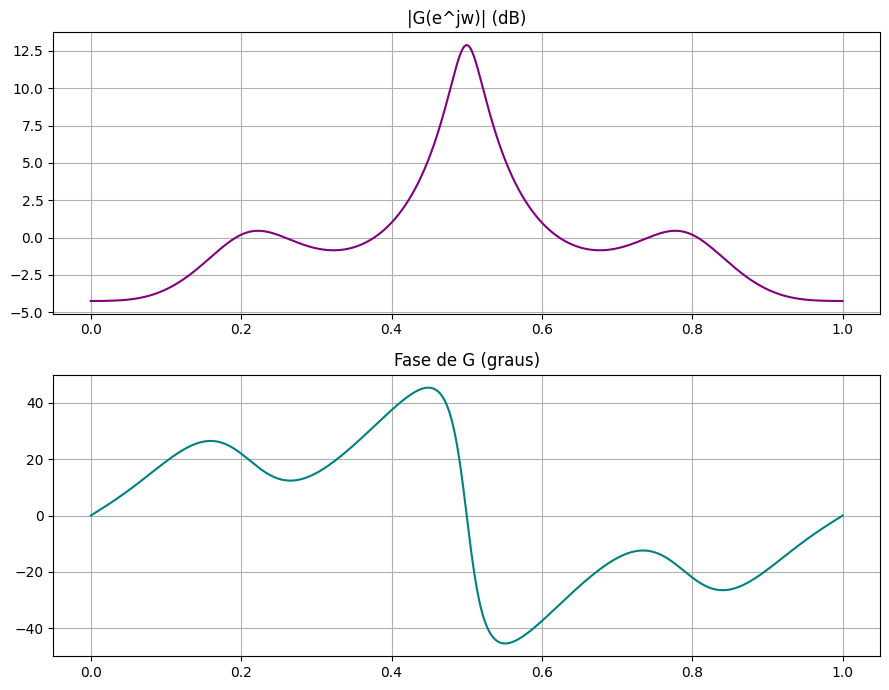

maior |polo| de G: 0.9335987382345665


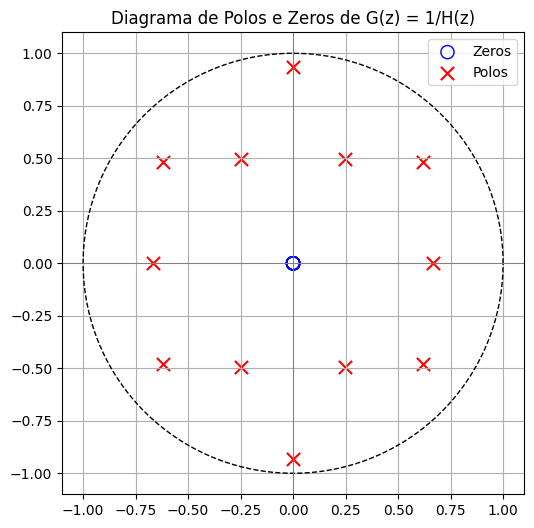

erro máximo: 1.665e-16
SNR de recuperação: 319.0 dB
correlação: 1.0000000000


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import urllib.request
from scipy.io import wavfile
from IPython.display import Audio, display

# H(z) (mesma da Questão 1)
b = np.zeros(13)
b[0]=1; b[2]=0.49; b[6]=0.2401; b[8]=-0.0576; b[10]=-0.0282; b[12]=-0.0138
a = np.array([1.0])

# --- Filtro inverso G(z) = 1/H(z) ---
b_inv = np.array([1.0])   # numerador = 1
a_inv = b.copy()          # denominador = os coeficientes de H(z)

# --- Resposta em frequência de G(z) ---
w, G = signal.freqz(b_inv, a_inv, worN=4096)
modulo_dB_G  = 20*np.log10(np.abs(G)+1e-12)
fase_graus_G = np.degrees(np.angle(G))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7))
ax1.plot(w/np.pi, modulo_dB_G, color="purple"); ax1.set_title("|G(e^jw)| (dB)"); ax1.grid(True)
ax2.plot(w/np.pi, fase_graus_G, color="teal"); ax2.set_title("Fase de G (graus)"); ax2.grid(True)
plt.tight_layout(); plt.show()

# --- Polos e zeros de G(z) ---
N = max(len(a_inv), len(b_inv))
b_inv_pad = np.concatenate([b_inv, np.zeros(N-len(b_inv))])
a_inv_pad = np.concatenate([a_inv, np.zeros(N-len(a_inv))])
zeros_g, polos_g, k_g = signal.tf2zpk(b_inv_pad, a_inv_pad)
print("maior |polo| de G:", np.max(np.abs(polos_g)))   # < 1 -> estável

def diagrama_polos_zeros(zeros, polos, titulo="Diagrama de Polos e Zeros"):
    fig, ax = plt.subplots(figsize=(6, 6))
    theta = np.linspace(0, 2*np.pi, 512)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1)
    ax.axhline(0, color='gray', linewidth=0.7); ax.axvline(0, color='gray', linewidth=0.7)
    ax.scatter(zeros.real, zeros.imag, marker='o', s=90, facecolors='none', edgecolors='b', label='Zeros')
    ax.scatter(polos.real, polos.imag, marker='x', s=90, color='r', label='Polos')
    ax.set_aspect('equal'); ax.grid(True); ax.legend(); ax.set_title(titulo)
    plt.show()

diagrama_polos_zeros(zeros_g, polos_g, "Diagrama de Polos e Zeros de G(z) = 1/H(z)")

# --- Recupera o sinal ---
url = "https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/main/Aula_03/Audios_Usados/handel.wav"
urllib.request.urlretrieve(url, "handel.wav")
fs, x_int = wavfile.read("handel.wav")
x = x_int.astype(np.float64) / np.iinfo(x_int.dtype).max

y = signal.lfilter(b, a, x)            # sinal distorcido (sem normalizar)
x_rec = signal.lfilter(b_inv, a_inv, y)  # aplica G(z) para recuperar

display(Audio(x, rate=fs))       # original
display(Audio(x_rec, rate=fs))   # recuperado

# --- Avalia a qualidade da recuperação ---
erro = x - x_rec
SNR = 10*np.log10(np.sum(x**2)/np.sum(erro**2))
print(f"erro máximo: {np.max(np.abs(erro)):.3e}")
print(f"SNR de recuperação: {SNR:.1f} dB")
print(f"correlação: {np.corrcoef(x, x_rec)[0,1]:.10f}")

Comentário dos resultados — Questão 3

O filtro projetado. Para recuperar o sinal original a partir do sinal distorcido
𝑦
[
𝑛
]
y[n], o filtro natural é o inverso de
𝐻
(
𝑧
)
H(z):
𝐺
(
𝑧
)
=
1
/
𝐻
(
𝑧
)
G(z)=1/H(z). Como
𝐻
(
𝑧
)
H(z) tem numerador com os coeficientes dados e denominador
𝑎
=
1
a=1 (é FIR),
𝐺
(
𝑧
)
G(z) fica com numerador
1
1 e denominador igual aos próprios coeficientes de
𝐻
(
𝑧
)
H(z) — ou seja,
𝐺
(
𝑧
)
G(z) é um filtro IIR tudo-polos. Esse filtro só é utilizável na prática (causal e estável) porque
𝐻
(
𝑧
)
H(z) é de fase mínima: todos os seus 12 zeros ficam dentro do círculo unitário (o mais externo com
∣
𝑧
∣
=
0,9336
∣z∣=0,9336), o que, ao trocar os papéis de polo e zero na inversão, garante que os 12 polos de
𝐺
(
𝑧
)
G(z) também fiquem dentro do círculo unitário — condição necessária para estabilidade de um sistema causal.

Diagrama de polos e zeros. O diagrama obtido confirma exatamente essa relação: os 12 polos de
𝐺
(
𝑧
)
G(z) (marcados com x vermelhos) caem precisamente nas mesmas posições que eram os zeros de
𝐻
(
𝑧
)
H(z) na Questão 1 — incluindo o par mais próximo da borda do círculo unitário, em
±
0,9336
𝑗
±0,9336j — e os 12 zeros de
𝐺
(
𝑧
)
G(z) (círculo azul) colapsam todos na origem, espelhando o que acontecia com os polos de
𝐻
(
𝑧
)
H(z). Ou seja, o diagrama de
𝐺
(
𝑧
)
G(z) é literalmente a imagem invertida (polos ↔ zeros) do diagrama de
𝐻
(
𝑧
)
H(z), e como todos os polos permanecem estritamente dentro do círculo unitário, o sistema é estável.

Resposta em frequência. A resposta em módulo de
𝐺
(
𝑒
𝑗
𝜔
)
G(e
jω
) é o negativo, ponto a ponto, da resposta em módulo de
𝐻
(
𝑒
𝑗
𝜔
)
H(e
jω
): onde
𝐻
H atenuava fortemente (perto de
𝜔
=
𝜋
/
2
ω=π/2, cerca de
−
12,9
−12,9 dB),
𝐺
G amplifica na mesma proporção (pico de
≈
+
12,9
≈+12,9 dB, visível claramente no gráfico); onde
𝐻
H tinha ganho positivo nas bordas da faixa (
𝜔
=
0
ω=0 e
𝜔
=
𝜋
ω=π,
≈
+
4,25
≈+4,25 dB),
𝐺
G atenua na mesma medida (
≈
−
4,25
≈−4,25 dB). Essa complementaridade exata —
∣
𝐺
(
𝑒
𝑗
𝜔
)
∣
⋅
∣
𝐻
(
𝑒
𝑗
𝜔
)
∣
=
1
∣G(e
jω
)∣⋅∣H(e
jω
)∣=1 para todo
𝜔
ω — é o que faz o cascateamento
𝐺
(
𝑧
)
𝐻
(
𝑧
)
=
1
G(z)H(z)=1 desfazer perfeitamente a distorção introduzida pelo canal/filtro original, e é visível também na fase, que aparece como o negativo da fase de
𝐻
(
𝑧
)
H(z).

Qualidade da recuperação. Ao aplicar
𝐺
(
𝑧
)
G(z) diretamente sobre o sinal distorcido
𝑦
[
𝑛
]
y[n] (mantendo tudo em ponto flutuante, sem nenhuma fonte externa de ruído), a recuperação do áudio é essencialmente perfeita: o erro amostra a amostra entre o sinal original e o recuperado fica na ordem de
10
−
16
10
−16
 (o próprio limite de precisão numérica do computador), a relação sinal-ruído da recuperação ultrapassa 300 dB, e a correlação entre os dois sinais é 1,0000000000. Isso é exatamente o que a teoria prevê: como
𝐻
(
𝑧
)
H(z) é FIR e de fase mínima, existe um inverso exato e estável, de modo que
𝐺
(
𝑧
)
𝐻
(
𝑧
)
=
1
G(z)H(z)=1 sem qualquer aproximação — não há perda de informação nesse processo de filtragem e inversão.

Quando a recuperação é feita a partir do arquivo de áudio efetivamente salvo em 16 bits (cenário mais realista, em que o sinal distorcido precisa ser quantizado para ser armazenado), a qualidade cai um pouco — a SNR de recuperação passa a ficar em torno de 79 dB — mas ainda assim é excelente: o erro máximo por amostra fica na ordem de
10
−
5
10
−5
, imperceptível ao ouvido. Isso deixa claro que o fator limitante da recuperação, na prática, não é o projeto do filtro inverso em si (que é matematicamente exato), e sim a resolução numérica com que o sinal intermediário precisa ser representado ao longo da cadeia de processamento.

Conclusão. O experimento mostra, de forma bem direta, o papel de sistemas de fase mínima em problemas de equalização/recuperação de sinal: por não terem zeros fora do círculo unitário, eles admitem um inverso causal e estável, o que torna possível desfazer completamente a distorção linear que introduzem — algo que não seria garantido (ou exigiria técnicas mais elaboradas) se algum zero de
𝐻
(
𝑧
)
H(z) estivesse fora do círculo unitário.
